<a href="https://colab.research.google.com/github/pejmanrasti/EPU_ML_Angers_2026/blob/main/Jour_3/Unet_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Entraînement d'un U-Net pour la Segmentation de Noyaux Cellulaires

## Introduction générale

Ce notebook vous guide pas à pas dans l'entraînement d'un réseau **U-Net 2D** pour segmenter des noyaux cellulaires à partir du jeu de données **Kaggle 2018 Data Science Bowl**.

### Qu'est-ce que la segmentation d'image ?

La segmentation consiste à **étiqueter chaque pixel** d'une image avec une classe (ici : noyau / fond). C'est une tâche plus précise que la classification ou la détection :

```
Classification  ->  "Il y a un noyau dans cette image"
Detection       ->  "Le noyau est a cette position (boite englobante)"
Segmentation    ->  "Ces pixels-ci appartiennent au noyau"
```

### Plan du notebook

1. 📦 Importation des bibliothèques
2. 🗂️ Chargement et prétraitement des données
3. 🏗️ Construction de l'architecture U-Net
4. 📐 Fonctions de perte et métriques
5. 🚀 Entraînement du modèle
6. 📊 Visualisation des courbes d'apprentissage
7. 🔍 Évaluation et prédictions
8. 🧪 Exercices complémentaires

> **⚙️ Prérequis matériel :** Activez le GPU dans *Édition → Paramètres du notebook → Accélérateur matériel*.

---
## 1. 📦 Importation des bibliothèques

| Bibliothèque | Rôle |
|---|---|
| `numpy` | Calcul matriciel (tableaux d'images) |
| `matplotlib` | Visualisation des images et courbes |
| `skimage` | Lecture et transformation d'images |
| `tensorflow / keras` | Construction et entraînement du réseau |
| `tqdm` | Barres de progression |

In [1]:
import os
import sys
import random
import warnings

import numpy as np
import pandas as pd
import imageio

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from tqdm import tqdm
from skimage.io import imread, imshow
from skimage.transform import resize
from skimage.morphology import label

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (Input, Conv2D, Conv2DTranspose,
                                     MaxPooling2D, concatenate,
                                     BatchNormalization, Activation,
                                     Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam

import tensorflow as tf

print(f'✅ TensorFlow version : {tf.__version__}')
print(f'✅ GPU disponible : {tf.config.list_physical_devices("GPU")}')

✅ TensorFlow version : 2.19.0
✅ GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2. 🗂️ Chargement et prétraitement des données

### Structure du jeu de données

```
nuclei_train_data/
├── <id_image_1>/
│   ├── images/
│   │   └── <id_image_1>.png     ← image microscopique (RGB)
│   └── masks/
│       ├── mask_noyau_1.png     ← masque binaire d'un noyau
│       ├── mask_noyau_2.png     ← un fichier par noyau !
│       └── ...
nuclei_val_data/
└── ...
```

> **Remarque :** Chaque noyau est fourni dans un fichier de masque **séparé**. Il faudra les **fusionner** en un seul masque binaire par image.

In [2]:
# Téléchargement du jeu de données
!gdown "https://drive.google.com/uc?id=1EbvS10-83JGNE2nlBxIV42izY1TOr115" -O kaggle_data.zip

Downloading...
From (original): https://drive.google.com/uc?id=1EbvS10-83JGNE2nlBxIV42izY1TOr115
From (redirected): https://drive.google.com/uc?id=1EbvS10-83JGNE2nlBxIV42izY1TOr115&confirm=t&uuid=d8b6c929-ccb9-403f-bf8f-f0b4358f3857
To: /content/kaggle_data.zip
100% 86.6M/86.6M [00:03<00:00, 28.1MB/s]


In [3]:
# Décompression et vérification
!unzip -qq kaggle_data.zip && rm kaggle_data.zip
print('✅ Données extraites.')
!ls

✅ Données extraites.
nuclei_train_data  nuclei_val_data  sample_data


### Exploration visuelle

**Règle d'or :** toujours explorer visuellement ses données avant d'écrire le moindre modèle !

**Questions à se poser :**
- Quelle est la résolution des images ?
- Les images sont-elles en couleur ou en niveaux de gris ?
- Les masques sont-ils binaires (0 ou 255) ?
- Y a-t-il des variations importantes d'apparence entre les images ?

In [4]:
# Explorer la structure des dossiers
print('=== Contenu de nuclei_train_data ===')
!ls nuclei_train_data | head -5
print()
sample_id = os.listdir('nuclei_train_data')[0]
print(f'=== Structure d un sous-dossier ({sample_id}) ===')
print('images/ :')
!ls nuclei_train_data/{sample_id}/images/
print('masks/ (5 premiers) :')
!ls nuclei_train_data/{sample_id}/masks/ | head -5
n_masks = len(os.listdir(f'nuclei_train_data/{sample_id}/masks/'))
print(f'-> {n_masks} masques individuels pour cette image')

=== Contenu de nuclei_train_data ===
003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1
00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e
0121d6759c5adb290c8e828fc882f37dfaf3663ec885c663859948c154a443ed
01d44a26f6680c42ba94c9bc6339228579a95d0e2695b149b7cc0c9592b21baf
0287e7ee5b007c91ae2bd7628d09735e70496bc6127ecb7f3dd043e04ce37426

=== Structure d un sous-dossier (cbca32daaae36a872a11da4eaff65d1068ff3f154eedc9d3fc0c214a4e5d32bd) ===
images/ :
cbca32daaae36a872a11da4eaff65d1068ff3f154eedc9d3fc0c214a4e5d32bd.png
masks/ (5 premiers) :
024c5c295c90406a9d3b1eca7f15d92a1b1f6b0f1e0beccb9540c14dfb28e125.png
030d84026bce875056063e060285115959270ad48cdcd4bac72412d4a7c53767.png
03a00123ba4f7d410e0ea64d4d02ba4ea39b0135888e2abcefe32a3095155044.png
075766ed00c4e966dfaed305aec53f2c5b36efff8bae8c20d7905fa1a02ba5cc.png
09470842aa53d054333db5750a1d82e85eabf763fc4ee607ac89cd52e503650e.png
-> 112 masques individuels pour cette image


/tmp/ipykernel_4255/2526962728.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)
/tmp/ipykernel_4255/2526962728.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  m = imageio.imread(mask_dir + mf)


Taille de l image originale : (256, 320, 4)


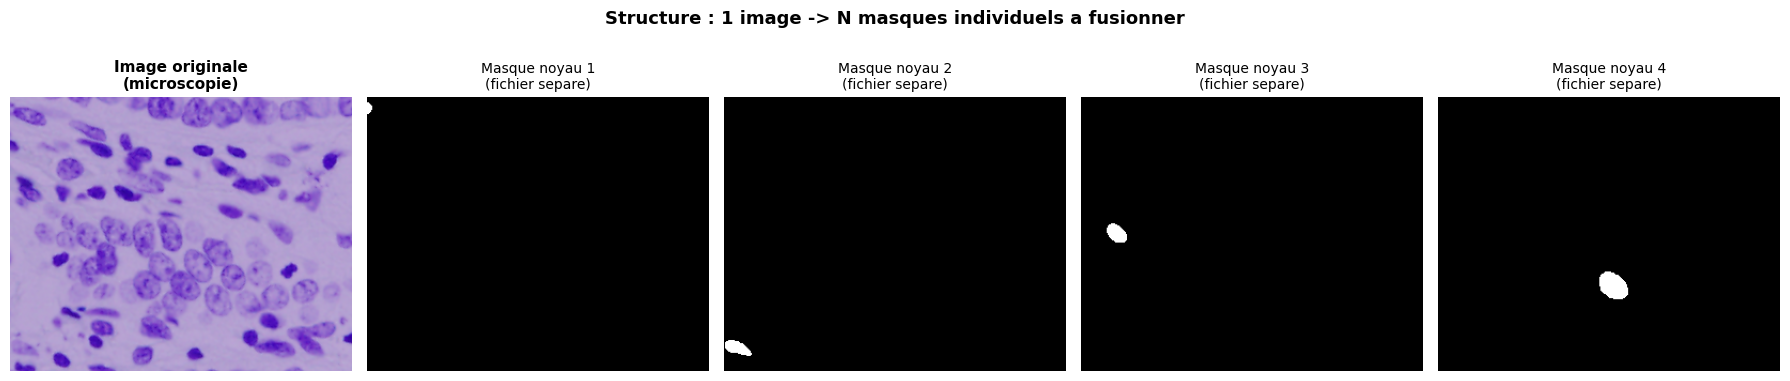

In [5]:
# Visualisation d'une image et de ses masques individuels
sample_id = os.listdir('nuclei_train_data')[0]
img_path  = f'nuclei_train_data/{sample_id}/images/{sample_id}.png'
mask_dir  = f'nuclei_train_data/{sample_id}/masks/'
mask_files = os.listdir(mask_dir)[:4]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
img = imageio.imread(img_path)
axes[0].imshow(img)
axes[0].set_title('Image originale\n(microscopie)', fontsize=11, fontweight='bold')
axes[0].axis('off')
print(f'Taille de l image originale : {img.shape}')

for i, mf in enumerate(mask_files):
    m = imageio.imread(mask_dir + mf)
    axes[i+1].imshow(m, cmap='gray')
    axes[i+1].set_title(f'Masque noyau {i+1}\n(fichier separe)', fontsize=10)
    axes[i+1].axis('off')

plt.suptitle('Structure : 1 image -> N masques individuels a fusionner',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Paramètres globaux et fonction de chargement

Trois opérations clés lors du prétraitement :
1. **Redimensionnement** à 256×256 (taille fixe requise par le réseau)
2. **Normalisation** des pixels dans \[0, 1\] (division par 255)
3. **Fusion** des masques individuels en un masque binaire unique (opération `maximum`)

In [6]:
# Paramètres globaux
IMG_WIDTH    = 256
IMG_HEIGHT   = 256
IMG_CHANNELS = 3
TRAIN_PATH   = 'nuclei_train_data/'
TEST_PATH    = 'nuclei_val_data/'

warnings.filterwarnings('ignore', category=UserWarning, module='skimage')
print(f'Dimensions cibles : {IMG_HEIGHT} x {IMG_WIDTH} x {IMG_CHANNELS}')

Dimensions cibles : 256 x 256 x 3


In [7]:
def get_data(path, train=True):
    # Charge toutes les images (et masques si train=True) d'un dossier.
    # Etapes :
    #   1. Lister les sous-dossiers (chaque sous-dossier = 1 echantillon)
    #   2. Lire l'image RGB, la redimensionner, normaliser dans [0,1]
    #   3. Fusionner tous les masques individuels via np.maximum
    #      (pixel=1 si au moins un masque le marque comme noyau)
    ids = next(os.walk(path))[1]
    X = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, 1),            dtype=np.float32)
    print(f'Chargement de {len(ids)} images depuis {path} ...')
    sys.stdout.flush()
    for n, id_ in tqdm(enumerate(ids), total=len(ids)):
        path_new = path + id_
        # -- Image
        img = imread(path_new + '/images/' + id_ + '.png')[:, :, :IMG_CHANNELS]
        img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
        X[n] = img / 255.0
        # -- Masques : fusion de tous les noyaux
        mask = np.zeros((IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.float32)
        for mask_file in next(os.walk(path_new + '/masks/'))[2]:
            m = imread(path_new + '/masks/' + mask_file)
            m = np.expand_dims(
                resize(m, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True),
                axis=-1)
            mask = np.maximum(mask, m / 255.0)
        Y[n] = mask
    return (X, Y) if train else X

In [8]:
X_train, Y_train = get_data(TRAIN_PATH, train=True)
X_test,  Y_test  = get_data(TEST_PATH,  train=True)

print(f'\n✅ Donnees chargees :')
print(f'   X_train : {X_train.shape}  (images entrainement)')
print(f'   Y_train : {Y_train.shape}  (masques entrainement)')
print(f'   X_test  : {X_test.shape}   (images test)')
print(f'   Y_test  : {Y_test.shape}   (masques test)')
print(f'\n   Pixels min/max (X_train) : {X_train.min():.2f} / {X_train.max():.2f}')
print(f'   Pixels min/max (Y_train) : {Y_train.min():.2f} / {Y_train.max():.2f}')

Chargement de 536 images depuis nuclei_train_data/ ...


100%|██████████| 536/536 [02:49<00:00,  3.16it/s]

Chargement de 134 images depuis nuclei_val_data/ ...



100%|██████████| 134/134 [00:49<00:00,  2.73it/s]



✅ Donnees chargees :
   X_train : (536, 256, 256, 3)  (images entrainement)
   Y_train : (536, 256, 256, 1)  (masques entrainement)
   X_test  : (134, 256, 256, 3)   (images test)
   Y_test  : (134, 256, 256, 1)   (masques test)

   Pixels min/max (X_train) : 0.00 / 1.00
   Pixels min/max (Y_train) : 0.00 / 1.00


Proportion de pixels noyau : 13.8%
-> Desequilibre classique en segmentation biologique/medicale.


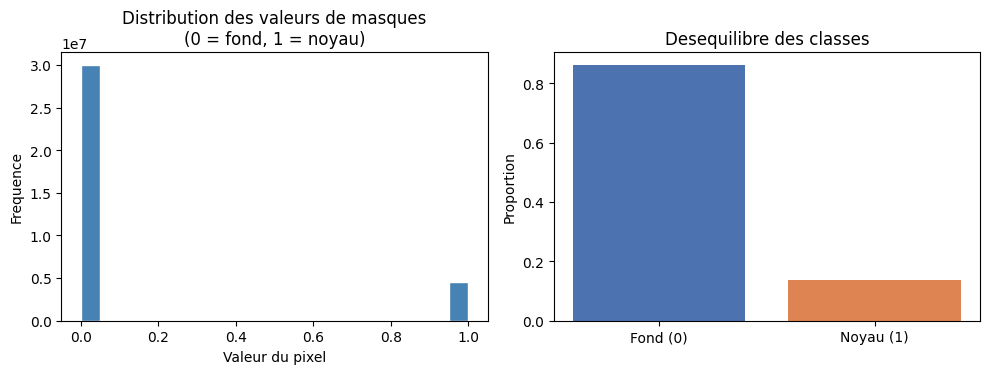

In [9]:
# Desequilibre des classes
foreground_ratio = float(Y_train.mean())
print(f'Proportion de pixels noyau : {foreground_ratio*100:.1f}%')
print('-> Desequilibre classique en segmentation biologique/medicale.')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(Y_train.flatten(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des valeurs de masques\n(0 = fond, 1 = noyau)')
axes[0].set_xlabel('Valeur du pixel')
axes[0].set_ylabel('Frequence')
axes[1].bar(['Fond (0)', 'Noyau (1)'],
            [1 - foreground_ratio, foreground_ratio],
            color=['#4C72B0', '#DD8452'])
axes[1].set_title('Desequilibre des classes')
axes[1].set_ylabel('Proportion')
plt.tight_layout()
plt.show()

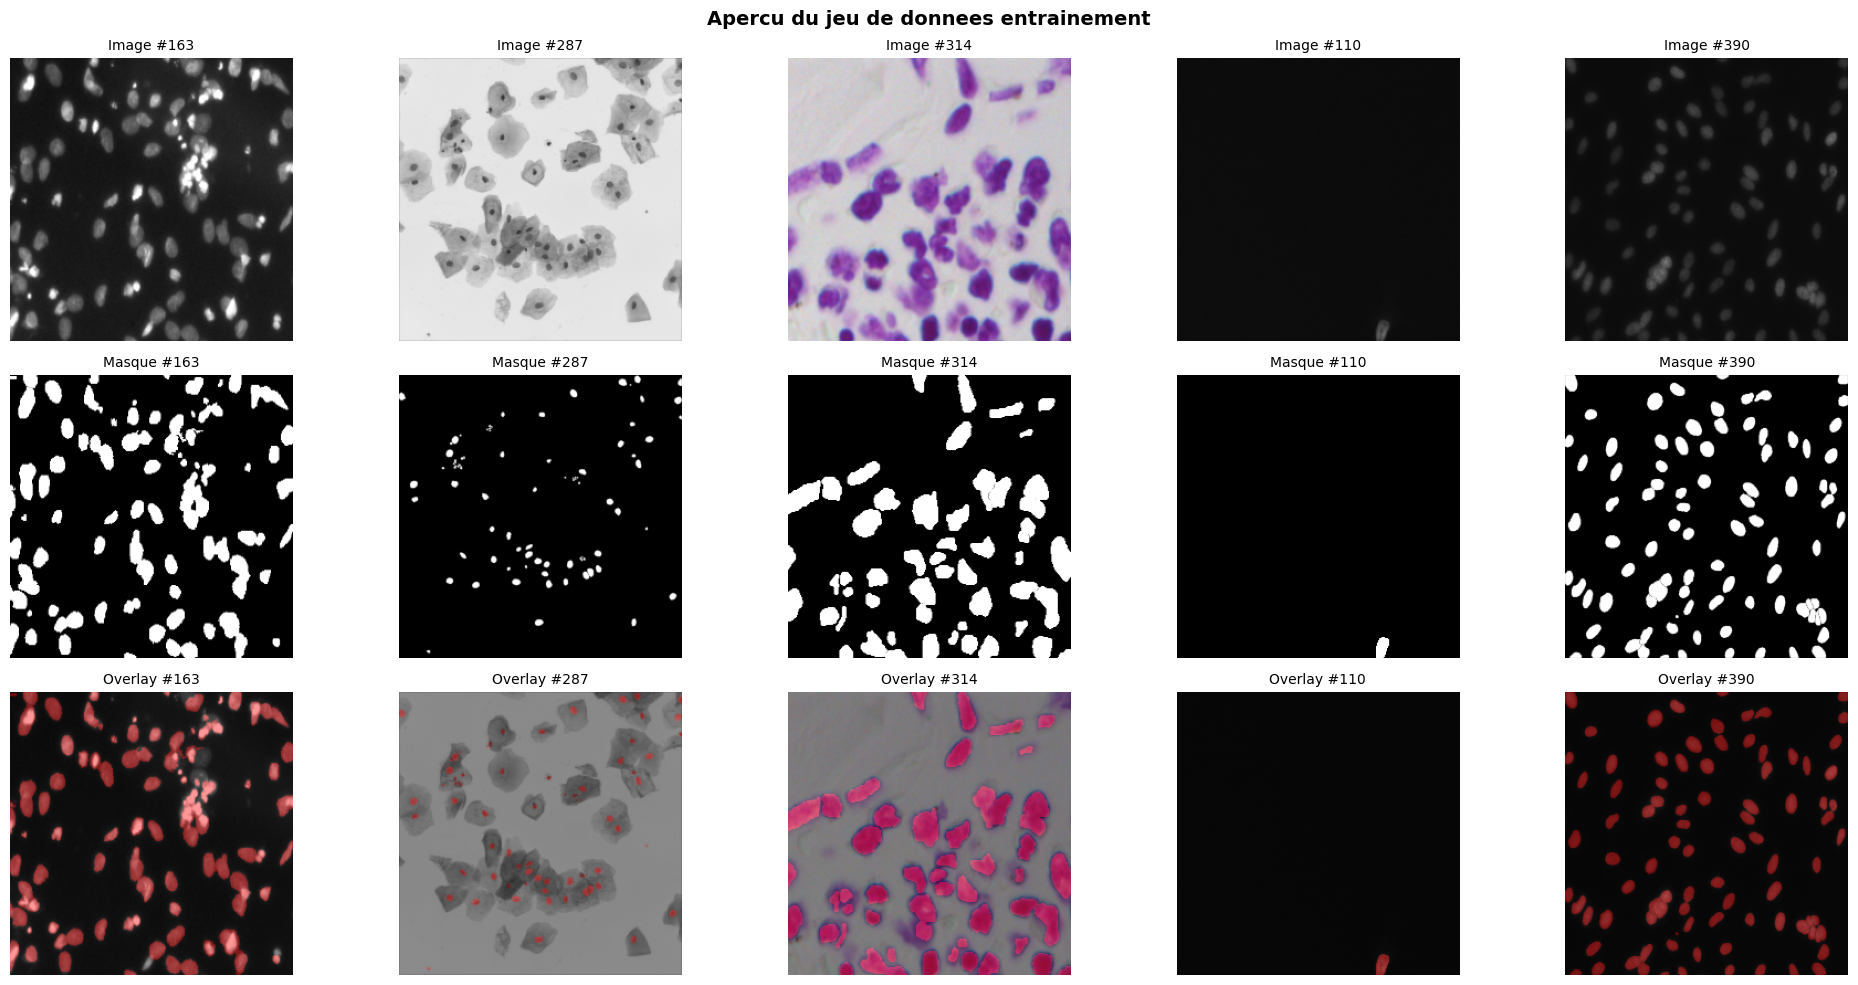

In [10]:
# Mosaique d'apercu : images + masques + superposition
n_samples = 5
indices   = random.sample(range(len(X_train)), n_samples)
fig, axes = plt.subplots(3, n_samples, figsize=(4 * n_samples, 10))

for col, ix in enumerate(indices):
    axes[0, col].imshow(X_train[ix])
    axes[0, col].set_title(f'Image #{ix}', fontsize=10)
    axes[0, col].axis('off')
    axes[1, col].imshow(np.squeeze(Y_train[ix]), cmap='gray')
    axes[1, col].set_title(f'Masque #{ix}', fontsize=10)
    axes[1, col].axis('off')
    overlay  = X_train[ix].copy()
    mask_rgb = np.zeros_like(overlay)
    mask_rgb[:, :, 0] = np.squeeze(Y_train[ix])
    axes[2, col].imshow(overlay)
    axes[2, col].imshow(mask_rgb, alpha=0.4)
    axes[2, col].set_title(f'Overlay #{ix}', fontsize=10)
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Images originales', fontsize=11, rotation=90, labelpad=15)
axes[1, 0].set_ylabel('Masques (verite terrain)', fontsize=11, rotation=90, labelpad=15)
axes[2, 0].set_ylabel('Superposition (overlay)', fontsize=11, rotation=90, labelpad=15)
plt.suptitle('Apercu du jeu de donnees entrainement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. 🏗️ Construction de l'architecture U-Net

### Histoire et motivation

Le **U-Net** a été proposé par Ronneberger et al. en 2015 (Université de Fribourg-en-Brisgau) spécifiquement pour la segmentation d'images biomédicales. Son nom vient de sa forme en **U** lorsqu'on représente l'architecture verticalement.

> **Référence :** Ronneberger, O., Fischer, P., & Brox, T. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation.* MICCAI 2015.

### Les trois composants clés

#### 1. Encodeur (chemin contractant)
- Blocs de **convolutions** (extraction de caractéristiques)
- Suivis de **MaxPooling 2×2** (résolution ÷2, filtres ×2)
- Capture le **quoi** mais perd le **où**

#### 2. Décodeur (chemin expansif)
- **Convolutions transposées** pour remonter en résolution
- **Connexions de saut** : concaténation avec la carte encodeur correspondante

#### 3. Connexions de saut ← *innovation centrale du U-Net*
Sans elles, le décodeur devrait reconstruire la position des noyaux depuis une représentation très compressée. Grâce à elles, les détails fins et les bords sont préservés.

```
Encodeur (contraction)             Decodeur (expansion)
--------------------------------------------------------------
Image (256x256x3)                   Masque (256x256x1)
      |                                     ^
Conv+Pool ------- skip connection --- UpConv+Concat
      |                                     ^
Conv+Pool ------- skip connection --- UpConv+Concat
      |                                     ^
Conv+Pool ------- skip connection --- UpConv+Concat
      |                                     ^
Conv+Pool ------- skip connection --- UpConv+Concat
      |
  Bottleneck (representation la plus compacte)
```

In [11]:
def conv2d_block(input_tensor, n_filters, kernel_size=3):
    # Bloc de base du U-Net : deux convolutions consecutives + activation ReLU.
    # Architecture : Input -> Conv2D(n_filters) -> ReLU -> Conv2D(n_filters) -> ReLU -> Output
    # Pourquoi deux convolutions ?
    # -> Deux Conv 3x3 ont un champ receptif equivalent a une Conv 5x5
    #    mais avec moins de parametres et une non-linearite supplementaire.

    # Premiere convolution
    x = Conv2D(filters=n_filters,
               kernel_size=(kernel_size, kernel_size),
               padding='same')(input_tensor)   # 'same' conserve la taille spatiale
    x = Activation('relu')(x)

    # Deuxieme convolution
    x = Conv2D(filters=n_filters,
               kernel_size=(kernel_size, kernel_size),
               padding='same')(x)
    x = Activation('relu')(x)

    return x

In [12]:
def get_unet(input_img, n_filters=4):
    # Construit le U-Net complet avec 4 niveaux + bottleneck.
    # Avec n_filters=4 : 16 / 32 / 64 / 128 / 256 filtres aux niveaux 1-2-3-4-bottleneck.
    # Sortie : Conv2D(1, 1x1) + sigmoid -> probabilite par pixel dans [0,1]

    # ============================================================
    # CHEMIN CONTRACTANT (Encodeur)
    # ============================================================
    # Niveau 1 : 256x256 -> 128x128  | 16 filtres
    c1 = conv2d_block(input_img, n_filters=n_filters * 4)   # (256,256,16)
    p1 = MaxPooling2D((2, 2))(c1)                           # (128,128,16)

    # Niveau 2 : 128x128 -> 64x64   | 32 filtres
    c2 = conv2d_block(p1, n_filters=n_filters * 8)          # (128,128,32)
    p2 = MaxPooling2D((2, 2))(c2)                           # (64,64,32)

    # Niveau 3 : 64x64 -> 32x32     | 64 filtres
    c3 = conv2d_block(p2, n_filters=n_filters * 16)         # (64,64,64)
    p3 = MaxPooling2D((2, 2))(c3)                           # (32,32,64)

    # Niveau 4 : 32x32 -> 16x16     | 128 filtres
    c4 = conv2d_block(p3, n_filters=n_filters * 32)         # (32,32,128)
    p4 = MaxPooling2D((2, 2))(c4)                           # (16,16,128)

    # ============================================================
    # BOTTLENECK - representation la plus comprimee et abstraite
    # ============================================================
    c5 = conv2d_block(p4, n_filters=n_filters * 64)         # (16,16,256)

    # ============================================================
    # CHEMIN EXPANSIF (Decodeur)
    # Chaque niveau : upsampling + skip connection + double convolution
    # ============================================================
    # Niveau 4 inverse : 16x16 -> 32x32
    u6 = Conv2DTranspose(n_filters * 32, (3, 3), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])          # <- skip connection encodeur niv.4
    c6 = conv2d_block(u6, n_filters=n_filters * 32)

    # Niveau 3 inverse : 32x32 -> 64x64
    u7 = Conv2DTranspose(n_filters * 16, (3, 3), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])          # <- skip connection encodeur niv.3
    c7 = conv2d_block(u7, n_filters=n_filters * 16)

    # Niveau 2 inverse : 64x64 -> 128x128
    u8 = Conv2DTranspose(n_filters * 8, (3, 3), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])          # <- skip connection encodeur niv.2
    c8 = conv2d_block(u8, n_filters=n_filters * 8)

    # Niveau 1 inverse : 128x128 -> 256x256
    u9 = Conv2DTranspose(n_filters * 4, (3, 3), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)  # <- skip connection encodeur niv.1
    c9 = conv2d_block(u9, n_filters=n_filters * 4)

    # ============================================================
    # COUCHE DE SORTIE
    # Conv 1x1 : N canaux -> 1 canal de probabilite par pixel
    # Sigmoid  : sortie dans [0,1]
    # ============================================================
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
    return Model(inputs=[input_img], outputs=[outputs])

In [13]:
# Instanciation et resume
input_img = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), name='img')
model = get_unet(input_img, n_filters=4)
print('=' * 60)
print('RESUME DE L ARCHITECTURE U-NET')
print('=' * 60)
model.summary()

RESUME DE L ARCHITECTURE U-NET


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img (InputLayer)    │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ img[0][0]         │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_4[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[

 Total params: 2,158,705 (8.23 MB)

 Trainable params: 2,158,705 (8.23 MB)

 Non-trainable params: 0 (0.00 B)

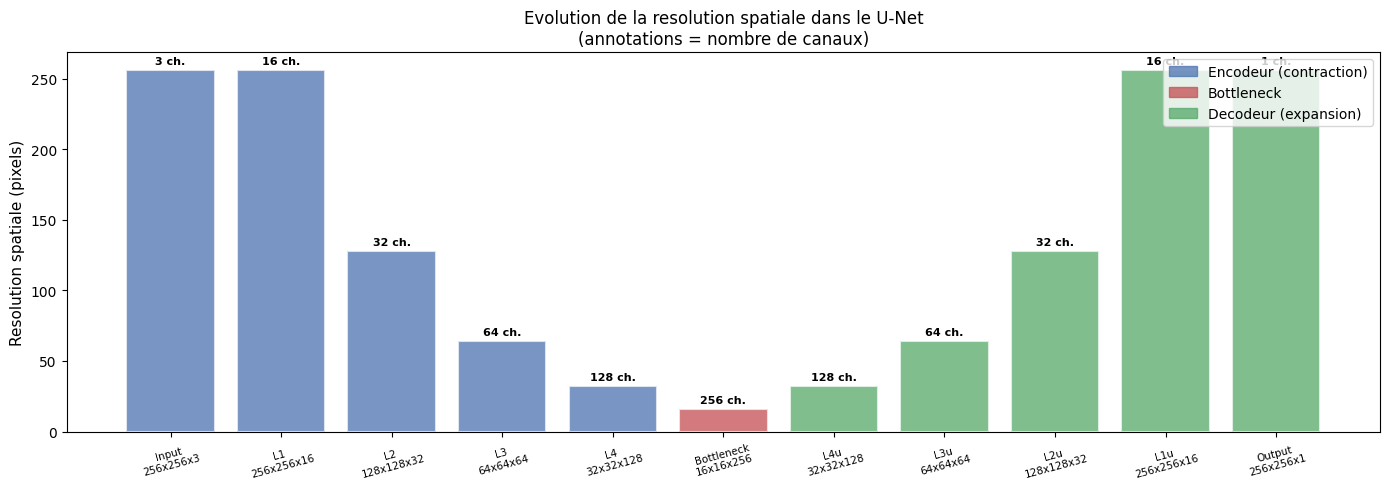

Parametres totaux : 2,158,705
Parametres entrainables : 2,158,705


In [14]:
# Visualisation de l'evolution spatiale a travers le reseau
levels   = ['Input\n256x256x3', 'L1\n256x256x16', 'L2\n128x128x32',
            'L3\n64x64x64', 'L4\n32x32x128', 'Bottleneck\n16x16x256',
            'L4u\n32x32x128', 'L3u\n64x64x64', 'L2u\n128x128x32',
            'L1u\n256x256x16', 'Output\n256x256x1']
spatial  = [256, 256, 128, 64, 32, 16, 32, 64, 128, 256, 256]
n_ch     = [3,   16,  32,  64, 128, 256, 128, 64, 32,  16,   1]
colors   = (['#4C72B0']*5) + ['#C44E52'] + (['#55A868']*5)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(levels)), spatial, color=colors, alpha=0.75, edgecolor='white', linewidth=1.5)
for xi, (s, c) in enumerate(zip(spatial, n_ch)):
    ax.text(xi, s + 3, f'{c} ch.', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(levels)))
ax.set_xticklabels(levels, fontsize=7.5, rotation=15)
ax.set_ylabel('Resolution spatiale (pixels)', fontsize=11)
ax.set_title('Evolution de la resolution spatiale dans le U-Net\n'
             '(annotations = nombre de canaux)', fontsize=12)
legend_patches = [
    mpatches.Patch(color='#4C72B0', alpha=0.75, label='Encodeur (contraction)'),
    mpatches.Patch(color='#C44E52', alpha=0.75, label='Bottleneck'),
    mpatches.Patch(color='#55A868', alpha=0.75, label='Decodeur (expansion)'),
]
ax.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.show()
total_params = model.count_params()
print(f'Parametres totaux : {total_params:,}')
print(f'Parametres entrainables : {sum(K.count_params(w) for w in model.trainable_weights):,}')

---
## 4. 📐 Fonctions de perte et métriques d'évaluation

### Pourquoi deux métriques ?

- **La perte (loss)** : utilisée pour l'optimisation par rétropropagation. Doit être différentiable.
- **La métrique d'évaluation** : utilisée pour comparer les performances. Peut être non différentiable.

### 4.1 Binary Cross-Entropy (BCE)

Pour chaque pixel, on compare la probabilité prédite $\hat{p}$ à la vérité terrain $y \in \{0, 1\}$ :

$$\mathcal{L}_{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

### 4.2 Coefficient de Dice

$$\text{Dice}(A, B) = \frac{2|A \cap B|}{|A| + |B|} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

- **Dice = 1** : segmentation parfaite ✅
- **Dice = 0** : aucun chevauchement ❌

> **Avantage du Dice :** robuste au déséquilibre des classes. Même si 95 % des pixels sont du fond, Dice ne sera élevé que si les noyaux sont bien segmentés.

In [15]:
def dice_coefficient(y_true, y_pred):
    # Coefficient de Dice entre verite terrain et prediction.
    # Formule : Dice = (2 * somme(y_true * y_pred)) / (somme(y_true^2) + somme(y_pred^2))
    # La version carree au denominateur ameliore la stabilite numerique.
    # Plage : [0, 1]  (0 = pire, 1 = meilleur)
    eps      = 1e-6
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection) / (
        K.sum(y_true_f * y_true_f) + K.sum(y_pred_f * y_pred_f) + eps
    )

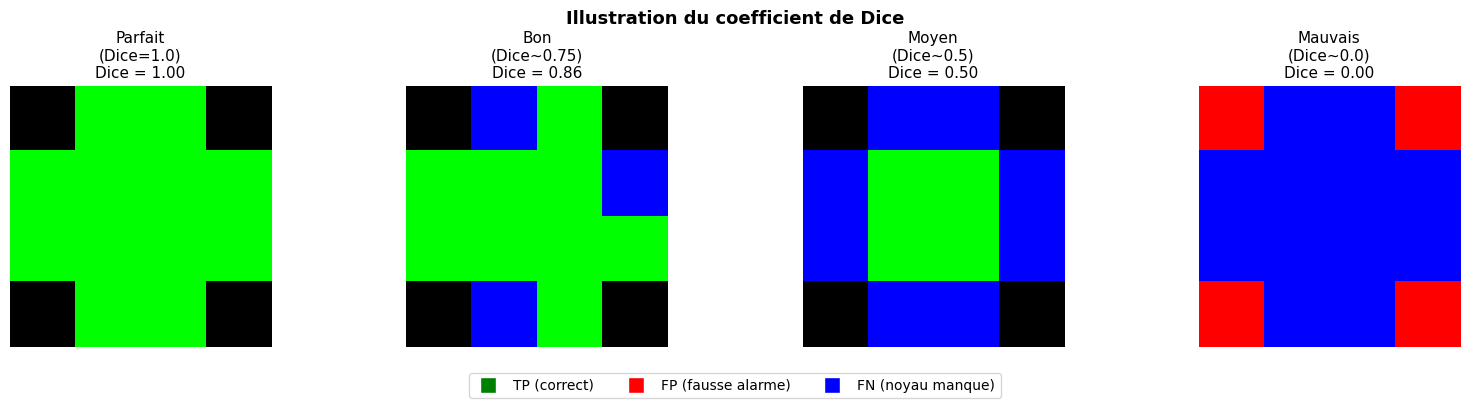

In [16]:
# Illustration intuitive du coefficient de Dice
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cases = [
    ('Parfait\n(Dice=1.0)',
     [[0,1,1,0],[1,1,1,1],[1,1,1,1],[0,1,1,0]],
     [[0,1,1,0],[1,1,1,1],[1,1,1,1],[0,1,1,0]]),
    ('Bon\n(Dice~0.75)',
     [[0,1,1,0],[1,1,1,1],[1,1,1,1],[0,1,1,0]],
     [[0,0,1,0],[1,1,1,0],[1,1,1,1],[0,0,1,0]]),
    ('Moyen\n(Dice~0.5)',
     [[0,1,1,0],[1,1,1,1],[1,1,1,1],[0,1,1,0]],
     [[0,0,0,0],[0,1,1,0],[0,1,1,0],[0,0,0,0]]),
    ('Mauvais\n(Dice~0.0)',
     [[0,1,1,0],[1,1,1,1],[1,1,1,1],[0,1,1,0]],
     [[1,0,0,1],[0,0,0,0],[0,0,0,0],[1,0,0,1]]),
]
for ax, (title, gt, pred) in zip(axes, cases):
    gt_a   = np.array(gt,   dtype=float)
    pred_a = np.array(pred, dtype=float)
    tp = np.sum(gt_a * pred_a)
    d  = 2 * tp / (np.sum(gt_a) + np.sum(pred_a) + 1e-6)
    overlay = np.zeros((4, 4, 3))
    overlay[:,:,1] = gt_a * pred_a          # vert  = TP
    overlay[:,:,0] = pred_a * (1 - gt_a)   # rouge = FP
    overlay[:,:,2] = gt_a * (1 - pred_a)   # bleu  = FN
    ax.imshow(overlay, interpolation='nearest')
    ax.set_title(f'{title}\nDice = {d:.2f}', fontsize=11)
    ax.axis('off')
legend = [
    Line2D([0],[0], marker='s', color='w', markerfacecolor='green', markersize=12, label='TP (correct)'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='red',   markersize=12, label='FP (fausse alarme)'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='blue',  markersize=12, label='FN (noyau manque)'),
]
fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=10)
plt.suptitle('Illustration du coefficient de Dice', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

---
## 5. 🚀 Compilation et entraînement du modèle

### Hyperparamètres

| Hyperparamètre | Valeur | Justification |
|---|---|---|
| Optimiseur | Adam | Adaptatif, converge rapidement |
| Taux d'apprentissage | 1e-3 (défaut Adam) | Bon compromis vitesse/stabilité |
| Perte | Binary Cross-Entropy | Standard pour segmentation binaire |
| Batch size | 5 | Petit batch → mémoire GPU réduite |
| Époques max | 15 | Suffisant pour observer la convergence |
| Validation split | 30 % | Suivi de la généralisation |

### Callbacks

Les **callbacks** sont des fonctions appelées automatiquement à chaque époque :
- **`EarlyStopping`** : arrête si la métrique ne s'améliore plus → évite le surapprentissage
- **`ModelCheckpoint`** : sauvegarde automatiquement le meilleur modèle

In [17]:
# Compilation
model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=[dice_coefficient]
)
print('✅ Modele compile.')
print('   Optimiseur : Adam (lr=1e-3 par defaut)')
print('   Perte      : binary_crossentropy')
print('   Metriques  : dice_coefficient')

✅ Modele compile.
   Optimiseur : Adam (lr=1e-3 par defaut)
   Perte      : binary_crossentropy
   Metriques  : dice_coefficient


In [18]:
# Callbacks
! pip install livelossplot
from livelossplot import PlotLossesKeras

callbacks = [
    EarlyStopping(
        monitor='val_dice_coefficient',  # surveille le Dice sur validation
        patience=5,                      # attend 5 epoques sans amelioration
        mode='max',                      # on veut maximiser le Dice
        verbose=1,
        restore_best_weights=True        # restaure les meilleurs poids
    ),
    ModelCheckpoint(
        filepath='best_unet_model.h5',
        monitor='val_dice_coefficient',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    plotlosses = PlotLossesKeras()
]
print('✅ Callbacks configures.')

✅ Callbacks configures.


In [19]:
# Entrainement
print('Demarrage de l entrainement...')
results = model.fit(
    X_train, Y_train,
    batch_size=5,
    epochs=15,
    validation_split=0.3,
    callbacks=callbacks,
    verbose=1
)
print('\n✅ Entrainement termine !')

Demarrage de l entrainement...
Epoch 1/15
74/75 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - dice_coefficient: 0.3368 - loss: 0.5690
Epoch 1: val_dice_coefficient improved from None to 0.42987, saving model to best_unet_model.h5



Epoch 1: finished saving model to best_unet_model.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 115ms/step - dice_coefficient: 0.3345 - loss: 0.4487 - val_dice_coefficient: 0.4299 - val_loss: 0.2851
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - dice_coefficient: 0.5315 - loss: 0.2609
Epoch 2: val_dice_coefficient improved from 0.42987 to 0.76111, saving model to best_unet_model.h5



Epoch 2: finished saving model to best_unet_model.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - dice_coefficient: 0.5788 - loss: 0.2436 - val_dice_coefficient: 0.7611 - val_loss: 0.1737
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_coefficient: 0.7417 - loss: 0.1918
Epoch 3: val_dice_coefficient did not improve from 0.76111
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - dice_coefficient: 0.7386 - loss: 0.1885 - val_dice_coefficient: 0.7566 - val_loss: 0.1769
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - dice_coefficient: 0.7556 - loss: 0.1647
Epoch 4: val_dice_coefficient improved from 0.76111 to 0.81934, saving model to best_unet_model.h5



Epoch 4: finished saving model to best_unet_model.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - dice_coefficient: 0.7890 - loss: 0.1567 - val_dice_coefficient: 0.8193 - val_loss: 0.1644
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - dice_coefficient: 0.8356 - loss: 0.1434
Epoch 5: val_dice_coefficient improved from 0.81934 to 0.88790, saving model to best_unet_model.h5



Epoch 5: finished saving model to best_unet_model.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - dice_coefficient: 0.8535 - loss: 0.1254 - val_dice_coefficient: 0.8879 - val_loss: 0.1076
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_coefficient: 0.8987 - loss: 0.0956
Epoch 6: val_dice_coefficient improved from 0.88790 to 0.89786, saving model to best_unet_model.h5



Epoch 6: finished saving model to best_unet_model.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - dice_coefficient: 0.8936 - loss: 0.0970 - val_dice_coefficient: 0.8979 - val_loss: 0.0950
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - dice_coefficient: 0.8918 - loss: 0.0918
Epoch 7: val_dice_coefficient did not improve from 0.89786
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - dice_coefficient: 0.8938 - loss: 0.0947 - val_dice_coefficient: 0.8855 - val_loss: 0.1021
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_coefficient: 0.9083 - loss: 0.0854
Epoch 8: val_dice_coefficient did not improve from 0.89786
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - dice_coefficient: 0.9127 - loss: 0.0808 - val_dice_coefficient: 0.8844 - val_loss: 0.1060
Epoch 9/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_coefficient: 0.9199 - loss: 0.0757
Epoch 9: val_dice_coefficient improved from 0.89786 to 0.91186, saving model to best_unet_model.h5



Epoch 9: finished saving model to best_unet_model.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - dice_coefficient: 0.9146 - loss: 0.0788 - val_dice_coefficient: 0.9119 - val_loss: 0.0913
Epoch 10/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_coefficient: 0.9200 - loss: 0.0749
Epoch 10: val_dice_coefficient did not improve from 0.91186
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - dice_coefficient: 0.9187 - loss: 0.0763 - val_dice_coefficient: 0.9045 - val_loss: 0.0851
Epoch 11/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_coefficient: 0.9223 - loss: 0.0760
Epoch 11: val_dice_coefficient did not improve from 0.91186
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - dice_coefficient: 0.9225 - loss: 0.0731 - val_dice_coefficient: 0.9040 - val_loss: 0.0854
Epoch 12/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_coefficient: 0.9189 - loss: 0.0697
Epoch 12: val_dice_coefficient improved from 0.91186 to 0.91586, saving model to best_unet_model.h5



Epoch 12: finished saving model to best_unet_model.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - dice_coefficient: 0.9181 - loss: 0.0739 - val_dice_coefficient: 0.9159 - val_loss: 0.0927
Epoch 13/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_coefficient: 0.9233 - loss: 0.0733
Epoch 13: val_dice_coefficient improved from 0.91586 to 0.91658, saving model to best_unet_model.h5



Epoch 13: finished saving model to best_unet_model.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - dice_coefficient: 0.9204 - loss: 0.0731 - val_dice_coefficient: 0.9166 - val_loss: 0.0863
Epoch 14/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_coefficient: 0.9175 - loss: 0.0761
Epoch 14: val_dice_coefficient improved from 0.91658 to 0.92553, saving model to best_unet_model.h5



Epoch 14: finished saving model to best_unet_model.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - dice_coefficient: 0.9218 - loss: 0.0714 - val_dice_coefficient: 0.9255 - val_loss: 0.0769
Epoch 15/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_coefficient: 0.9254 - loss: 0.0691
Epoch 15: val_dice_coefficient did not improve from 0.92553
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - dice_coefficient: 0.9233 - loss: 0.0727 - val_dice_coefficient: 0.9212 - val_loss: 0.0809
Restoring model weights from the end of the best epoch: 14.

✅ Entrainement termine !


---
## 6. 📊 Visualisation des courbes d'apprentissage

Les courbes d'apprentissage sont **indispensables** pour diagnostiquer l'entraînement :

| Situation | Symptôme | Solution |
|---|---|---|
| **Sous-apprentissage** | Loss train élevée ET loss val élevée | Augmenter la complexité |
| **Surapprentissage** | Loss train basse MAIS loss val remonte | Dropout, augmentation, early stopping |
| **Bon apprentissage** | Les deux courbes convergent ensemble | ✅ |

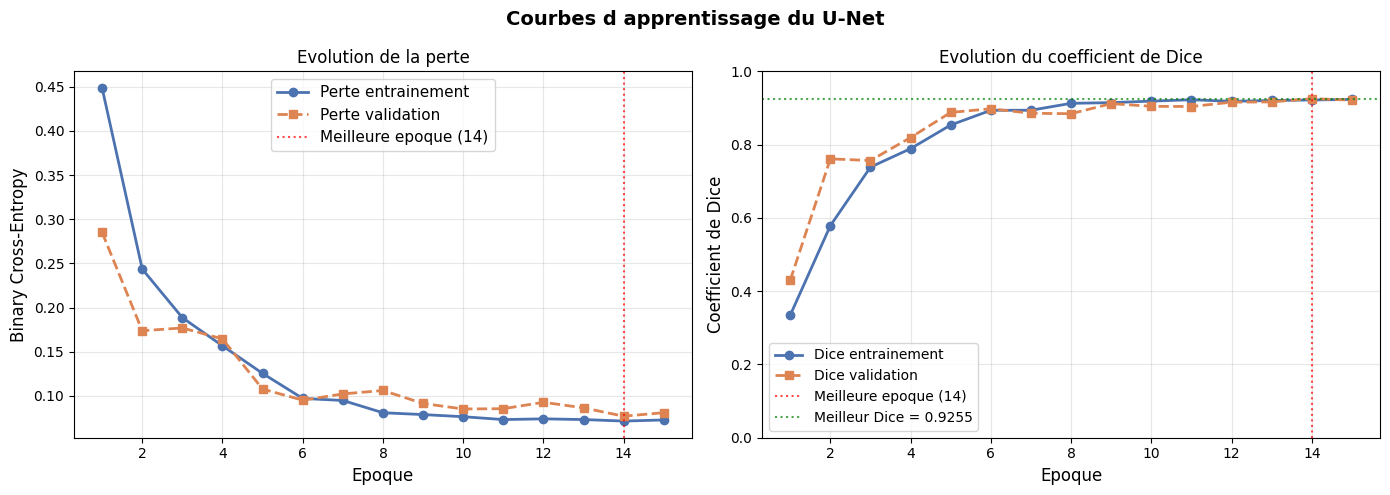

RESUME DES PERFORMANCES
  Epoques realisees       : 15
  Meilleure perte (val)   : 0.0769  (epoque 14)
  Meilleur Dice (val)     : 0.9255  (epoque 14)
  Ecart train/val (Dice)  : 0.0020
  Tres bonne generalisation (gap < 0.02)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(results.history['loss']) + 1)

# -- Courbe de perte
axes[0].plot(epochs_range, results.history['loss'],
             'o-', color='#4C72B0', lw=2, label='Perte entrainement')
axes[0].plot(epochs_range, results.history['val_loss'],
             's--', color='#DD8452', lw=2, label='Perte validation')
best_loss_ep = int(np.argmin(results.history['val_loss'])) + 1
axes[0].axvline(x=best_loss_ep, color='red', ls=':', alpha=0.7,
                label=f'Meilleure epoque ({best_loss_ep})')
axes[0].set_xlabel('Epoque', fontsize=12)
axes[0].set_ylabel('Binary Cross-Entropy', fontsize=12)
axes[0].set_title('Evolution de la perte', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# -- Courbe de Dice
axes[1].plot(epochs_range, results.history['dice_coefficient'],
             'o-', color='#4C72B0', lw=2, label='Dice entrainement')
axes[1].plot(epochs_range, results.history['val_dice_coefficient'],
             's--', color='#DD8452', lw=2, label='Dice validation')
best_dice_ep  = int(np.argmax(results.history['val_dice_coefficient'])) + 1
best_dice_val = float(max(results.history['val_dice_coefficient']))
axes[1].axvline(x=best_dice_ep, color='red', ls=':', alpha=0.7,
                label=f'Meilleure epoque ({best_dice_ep})')
axes[1].axhline(y=best_dice_val, color='green', ls=':', alpha=0.7,
                label=f'Meilleur Dice = {best_dice_val:.4f}')
axes[1].set_xlabel('Epoque', fontsize=12)
axes[1].set_ylabel('Coefficient de Dice', fontsize=12)
axes[1].set_title('Evolution du coefficient de Dice', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.suptitle('Courbes d apprentissage du U-Net', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Resume numerique
print('=' * 50)
print('RESUME DES PERFORMANCES')
print('=' * 50)
print(f'  Epoques realisees       : {len(results.history["loss"])}')
print(f'  Meilleure perte (val)   : {min(results.history["val_loss"]):.4f}  (epoque {best_loss_ep})')
print(f'  Meilleur Dice (val)     : {best_dice_val:.4f}  (epoque {best_dice_ep})')
gap = float(results.history['dice_coefficient'][-1]) - float(results.history['val_dice_coefficient'][-1])
print(f'  Ecart train/val (Dice)  : {gap:.4f}')
if   gap > 0.15: print('  Possible surapprentissage (gap > 0.15)')
elif gap < 0.02: print('  Tres bonne generalisation (gap < 0.02)')
else:            print('  Generalisation acceptable')

---
## 7. 🔍 Évaluation et visualisation des prédictions

### Processus en trois étapes

1. **`model.evaluate`** → perte et Dice sur données de test (jamais vues pendant l'entraînement)
2. **`model.predict`** → cartes de probabilité continues ∈ \[0, 1\]
3. **Seuillage** → masques binaires (seuil typique = 0.5)

In [21]:
# Evaluation quantitative
print('Evaluation sur les donnees de test...')
test_loss, test_dice = model.evaluate(X_test, Y_test, verbose=1)
print(f'\n{"="*45}')
print(f'  Perte (BCE) sur test  : {test_loss:.4f}')
print(f'  Dice sur test         : {test_dice:.4f}')
print(f'{"="*45}')
if   test_dice >= 0.85: print('  Excellent (>= 0.85)')
elif test_dice >= 0.70: print('  Bon (0.70-0.85)')
elif test_dice >= 0.50: print('  Moyen (0.50-0.70)')
else:                   print('  Insuffisant (< 0.50)')

Evaluation sur les donnees de test...
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - dice_coefficient: 0.9167 - loss: 0.0685

  Perte (BCE) sur test  : 0.0685
  Dice sur test         : 0.9167
  Excellent (>= 0.85)


In [22]:
# Predictions
preds_test   = model.predict(X_test, verbose=1)
preds_test_t = (preds_test > 0.5).astype(np.uint8)
print(f'\nPredictions generees :')
print(f'   preds_test   : {preds_test.shape}  (probabilites continues dans [0,1])')
print(f'   preds_test_t : {preds_test_t.shape} (masques binaires apres seuil 0.5)')

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step

Predictions generees :
   preds_test   : (134, 256, 256, 1)  (probabilites continues dans [0,1])
   preds_test_t : (134, 256, 256, 1) (masques binaires apres seuil 0.5)


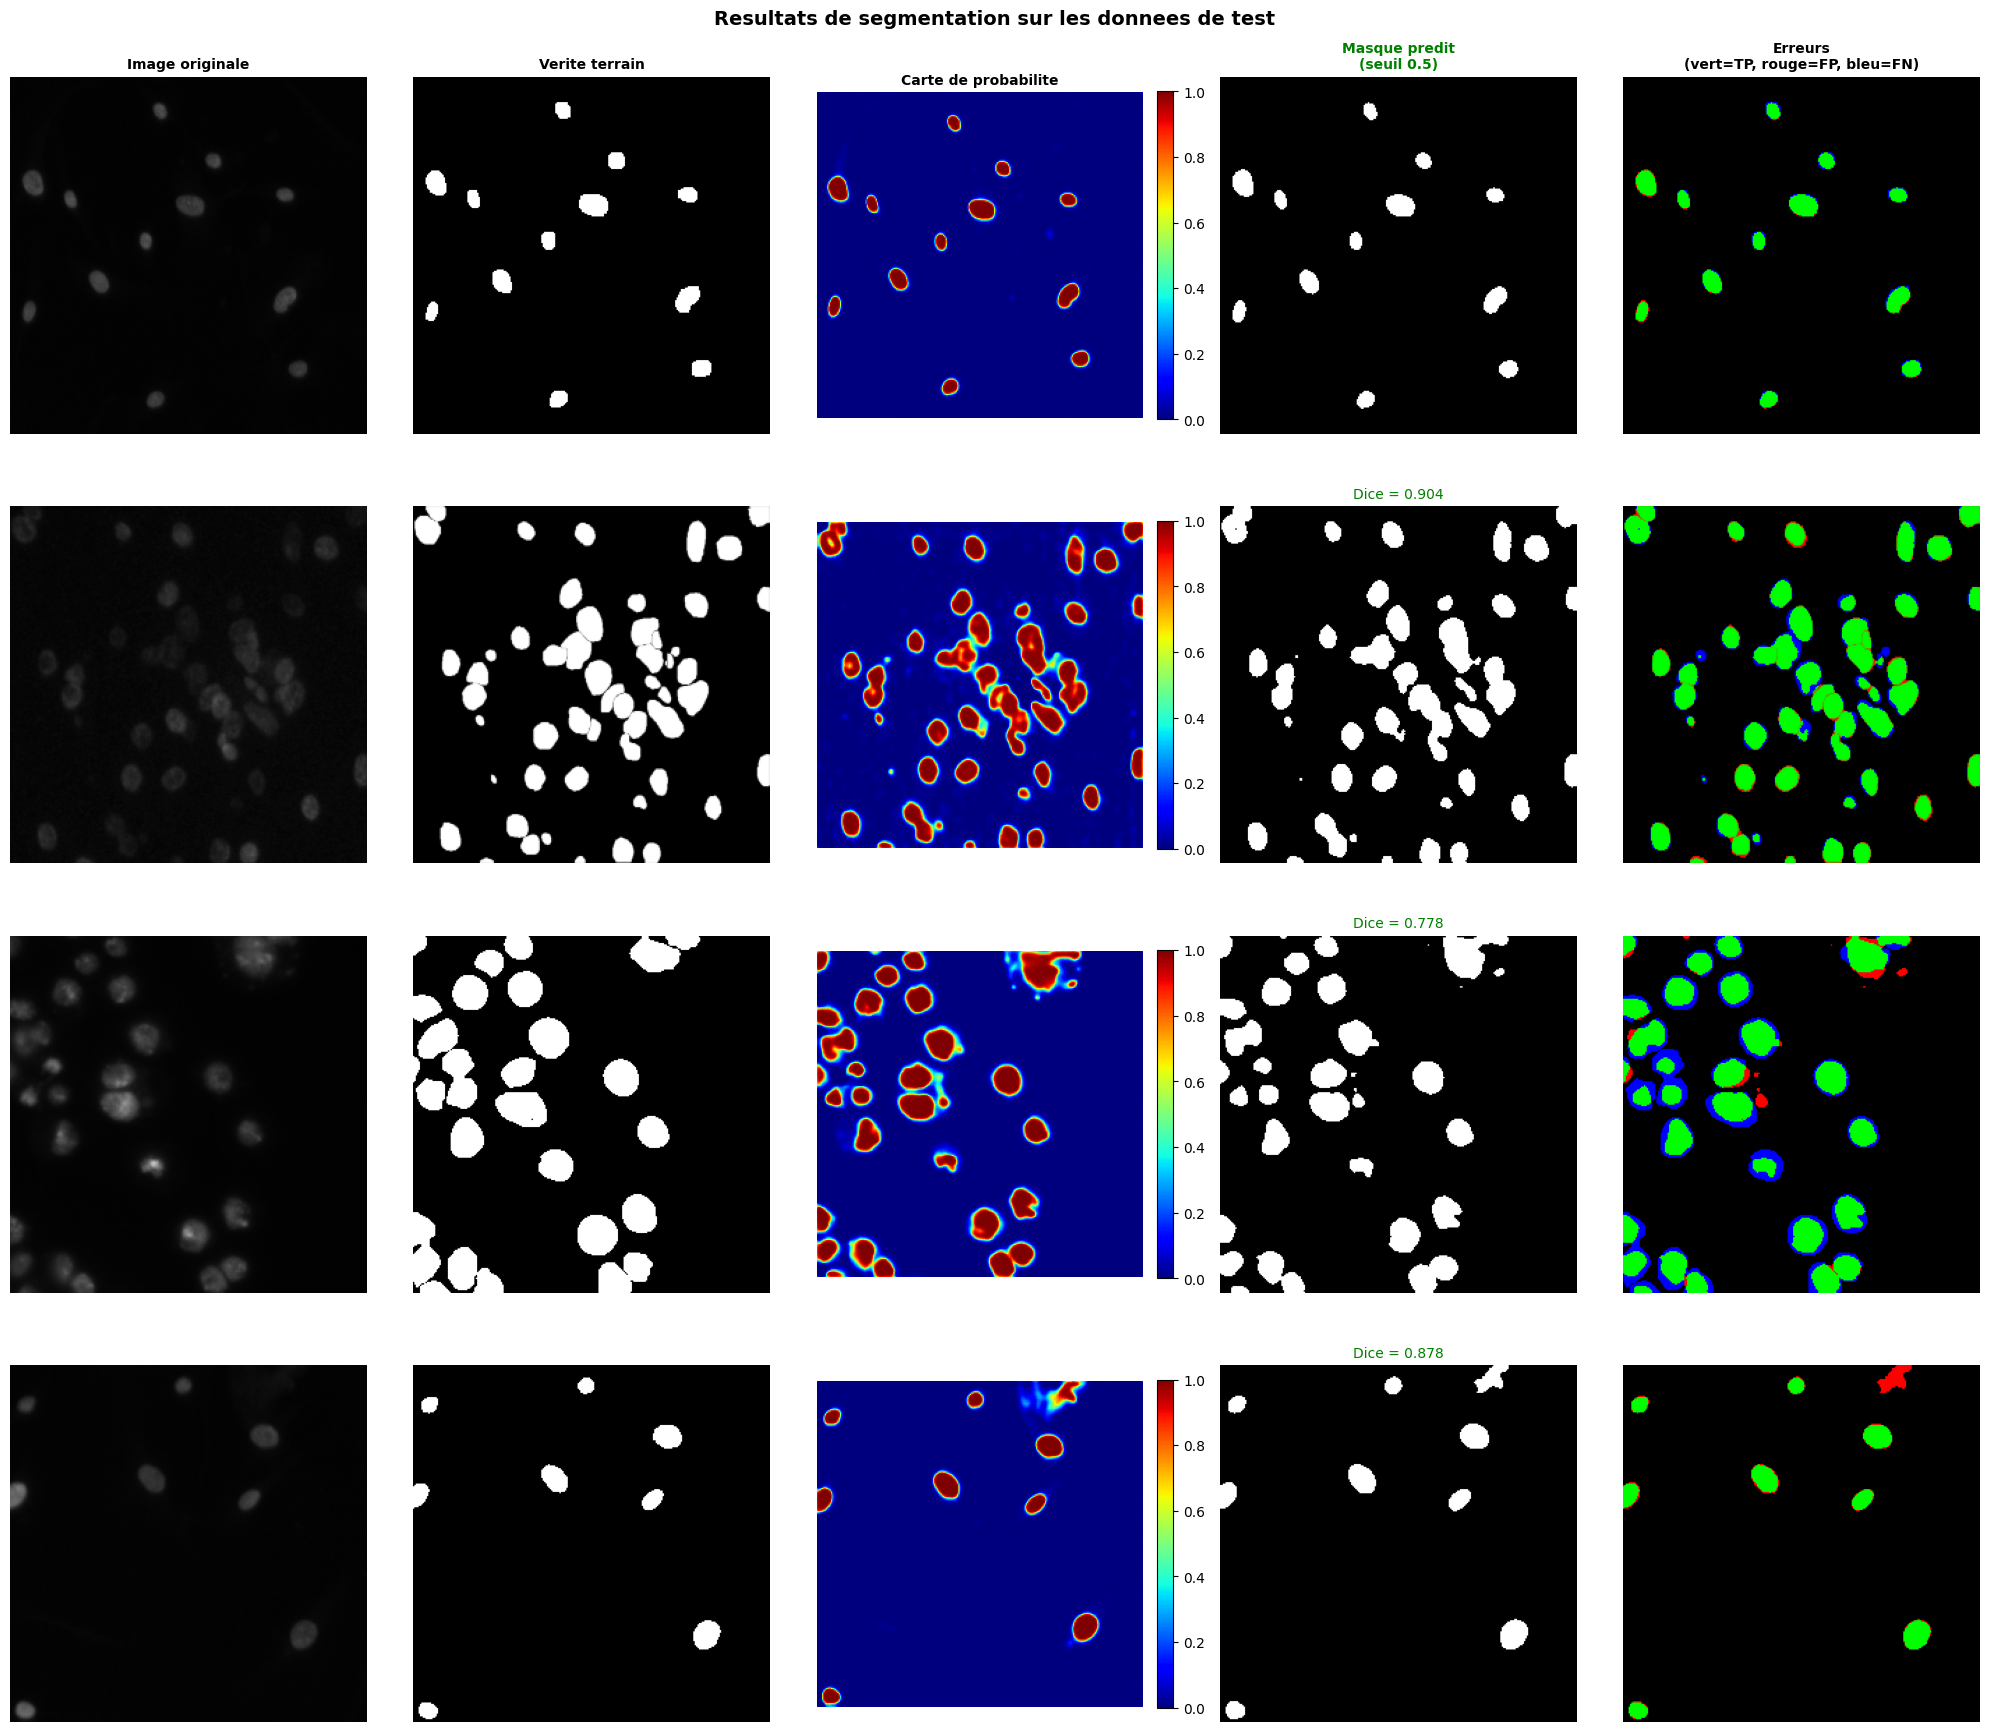

In [23]:
# Visualisation detaillee : 4 exemples
n_examples = 4
indices    = random.sample(range(len(X_test)), n_examples)
fig, axes  = plt.subplots(n_examples, 5, figsize=(20, 4.5 * n_examples))
col_titles = ['Image originale', 'Verite terrain',
              'Carte de probabilite', 'Masque predit\n(seuil 0.5)',
              'Erreurs\n(vert=TP, rouge=FP, bleu=FN)']

for row, ix in enumerate(indices):
    img    = X_test[ix]
    gt     = np.squeeze(Y_test[ix])
    prob   = np.squeeze(preds_test[ix])
    pred_b = np.squeeze(preds_test_t[ix]).astype(float)
    fp        = pred_b * (1 - gt)
    fn        = (1 - pred_b) * gt
    error_map = np.zeros((*gt.shape, 3))
    error_map[:,:,1] = pred_b * gt   # vert  = TP
    error_map[:,:,0] = fp            # rouge = FP
    error_map[:,:,2] = fn            # bleu  = FN
    tp      = float(np.sum(pred_b * gt))
    dice_ex = 2 * tp / (float(np.sum(pred_b)) + float(np.sum(gt)) + 1e-6)
    axes[row, 0].imshow(img)
    axes[row, 1].imshow(gt,     cmap='gray')
    im = axes[row, 2].imshow(prob, cmap='jet', vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)
    axes[row, 3].imshow(pred_b, cmap='gray')
    axes[row, 4].imshow(error_map)
    color = 'green' if dice_ex > 0.7 else 'red'
    axes[row, 3].set_title(f'Dice = {dice_ex:.3f}', fontsize=10, color=color)
    axes[row, 0].set_ylabel(f'Image #{ix}', fontsize=10)
    for col in range(5): axes[row, col].axis('off')

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold')
plt.suptitle('Resultats de segmentation sur les donnees de test',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

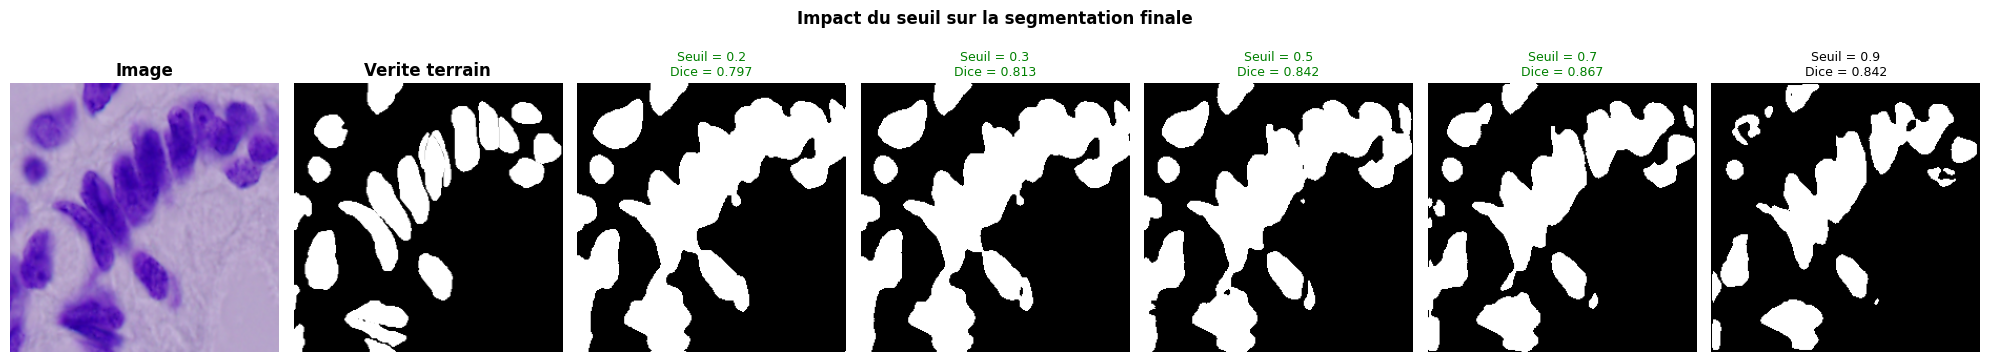

-> Meilleur seuil parmi [0.2, 0.3, 0.5, 0.7, 0.9] : 0.7  (Dice = 0.8665)


In [24]:
# Impact du seuil de decision
ix       = random.randint(0, len(X_test) - 1)
prob_map = np.squeeze(preds_test[ix])
gt_map   = np.squeeze(Y_test[ix])

thresholds = [0.2, 0.3, 0.5, 0.7, 0.9]
fig, axes  = plt.subplots(1, len(thresholds) + 2, figsize=(20, 4))
axes[0].imshow(X_test[ix]); axes[0].set_title('Image', fontweight='bold'); axes[0].axis('off')
axes[1].imshow(gt_map, cmap='gray'); axes[1].set_title('Verite terrain', fontweight='bold'); axes[1].axis('off')

dice_scores = []
for ax, thr in zip(axes[2:], thresholds):
    binary = (prob_map > thr).astype(float)
    tp  = float(np.sum(binary * gt_map))
    d   = 2 * tp / (float(np.sum(binary)) + float(np.sum(gt_map)) + 1e-6)
    dice_scores.append(d)
    ax.imshow(binary, cmap='gray')
    ax.set_title(f'Seuil = {thr}\nDice = {d:.3f}', fontsize=9,
                 color='green' if d == max(dice_scores) else 'black')
    ax.axis('off')

plt.suptitle('Impact du seuil sur la segmentation finale', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
best_thr = thresholds[int(np.argmax(dice_scores))]
print(f'-> Meilleur seuil parmi {thresholds} : {best_thr}  (Dice = {max(dice_scores):.4f})')

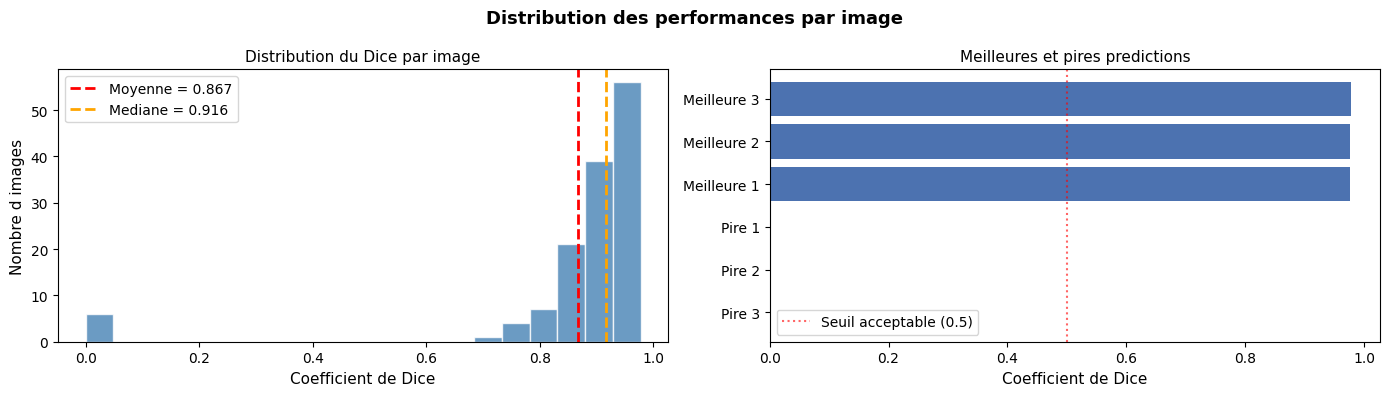

Statistiques Dice (test) :
   Moyenne : 0.8668
   Mediane : 0.9160
   Std     : 0.1927
   Min     : 0.0000
   Max     : 0.9777


In [25]:
# Distribution du Dice sur tout le jeu de test
per_image_dice = []
for i in range(len(X_test)):
    gt_i   = np.squeeze(Y_test[i])
    pred_i = np.squeeze(preds_test_t[i]).astype(float)
    tp = float(np.sum(pred_i * gt_i))
    d  = 2 * tp / (float(np.sum(pred_i)) + float(np.sum(gt_i)) + 1e-6)
    per_image_dice.append(d)
per_image_dice = np.array(per_image_dice)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(per_image_dice, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(per_image_dice.mean(), color='red', ls='--', lw=2, label=f'Moyenne = {per_image_dice.mean():.3f}')
axes[0].axvline(np.median(per_image_dice), color='orange', ls='--', lw=2, label=f'Mediane = {np.median(per_image_dice):.3f}')
axes[0].set_xlabel('Coefficient de Dice', fontsize=11)
axes[0].set_ylabel('Nombre d images', fontsize=11)
axes[0].set_title('Distribution du Dice par image', fontsize=11)
axes[0].legend()

sorted_idx = np.argsort(per_image_dice)
labels     = ['Pire 3', 'Pire 2', 'Pire 1', 'Meilleure 1', 'Meilleure 2', 'Meilleure 3']
values     = [per_image_dice[i] for i in list(sorted_idx[:3]) + list(sorted_idx[-3:])]
axes[1].barh(labels, values, color=['#DD8452']*3 + ['#4C72B0']*3)
axes[1].axvline(0.5, color='red', ls=':', alpha=0.6, label='Seuil acceptable (0.5)')
axes[1].set_xlabel('Coefficient de Dice', fontsize=11)
axes[1].set_title('Meilleures et pires predictions', fontsize=11)
axes[1].legend()

plt.suptitle('Distribution des performances par image', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Statistiques Dice (test) :')
print(f'   Moyenne : {per_image_dice.mean():.4f}')
print(f'   Mediane : {np.median(per_image_dice):.4f}')
print(f'   Std     : {per_image_dice.std():.4f}')
print(f'   Min     : {per_image_dice.min():.4f}')
print(f'   Max     : {per_image_dice.max():.4f}')

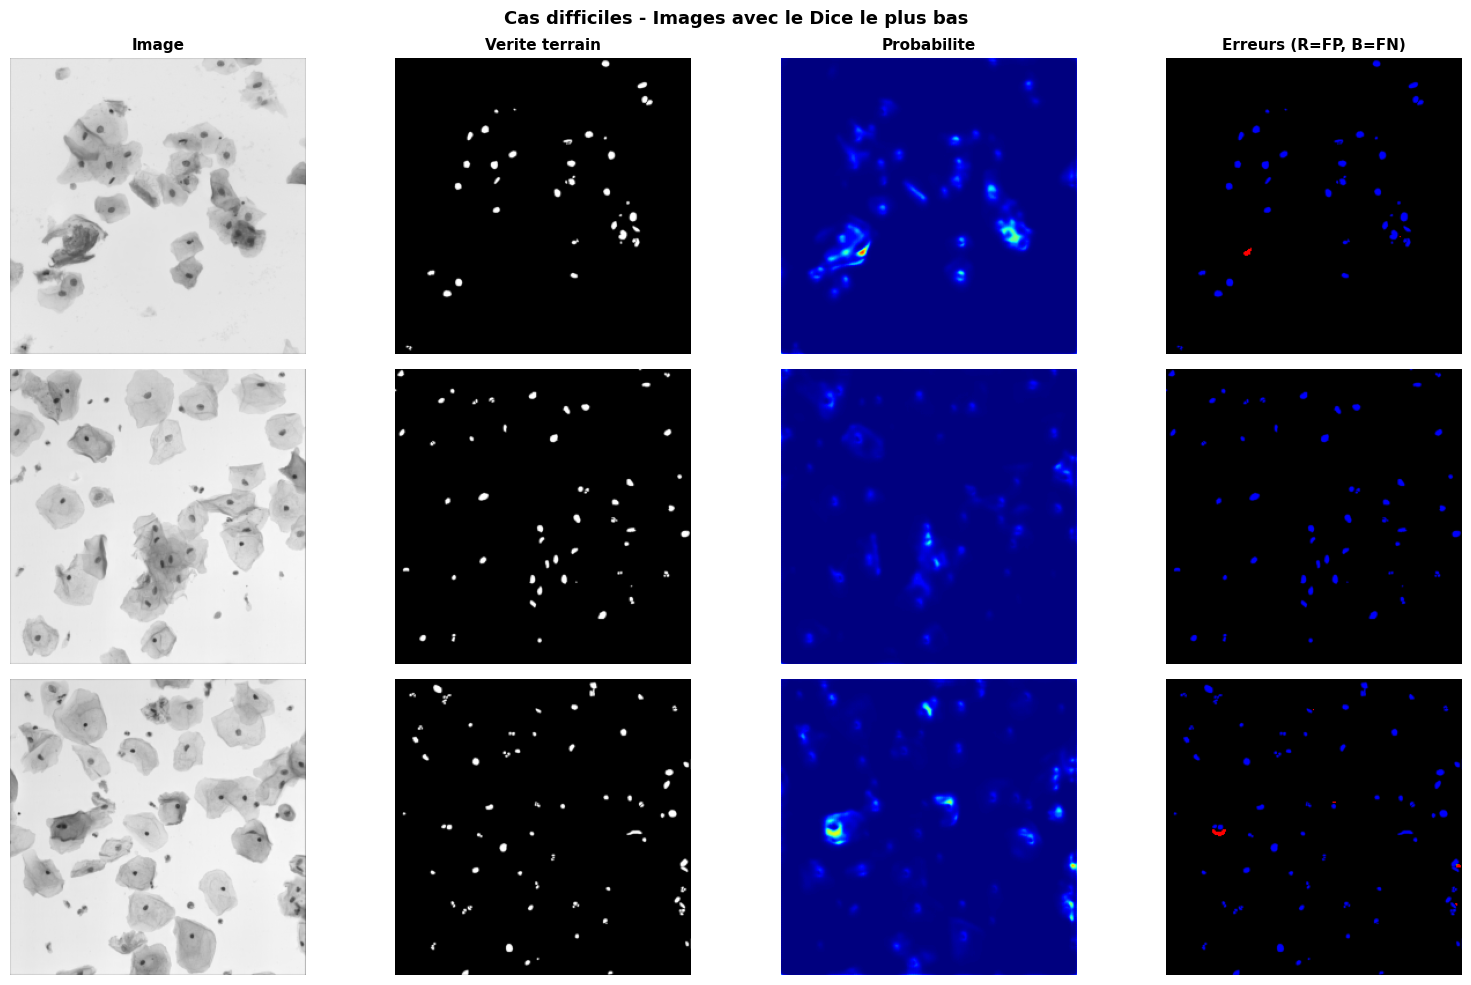

In [26]:
# Zoom sur les cas difficiles (Dice le plus bas)
worst_3 = np.argsort(per_image_dice)[:3]
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for row, ix in enumerate(worst_3):
    gt     = np.squeeze(Y_test[ix])
    prob   = np.squeeze(preds_test[ix])
    pred_b = np.squeeze(preds_test_t[ix]).astype(float)
    error_map = np.zeros((*gt.shape, 3))
    error_map[:,:,1] = pred_b * gt
    error_map[:,:,0] = pred_b * (1 - gt)
    error_map[:,:,2] = (1 - pred_b) * gt
    axes[row, 0].imshow(X_test[ix])
    axes[row, 0].set_ylabel(f'Image #{ix}\nDice={per_image_dice[ix]:.3f}', fontsize=10)
    axes[row, 1].imshow(gt, cmap='gray')
    axes[row, 2].imshow(prob, cmap='jet', vmin=0, vmax=1)
    axes[row, 3].imshow(error_map)
    for col in range(4): axes[row, col].axis('off')
for col, t in enumerate(['Image', 'Verite terrain', 'Probabilite', 'Erreurs (R=FP, B=FN)']):
    axes[0, col].set_title(t, fontsize=11, fontweight='bold')
plt.suptitle('Cas difficiles - Images avec le Dice le plus bas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. 🧪 Exercices complémentaires

### Exercice 1 : Variantes d'architecture

Implémentez et comparez au moins **2 variantes** du U-Net :

#### a) U-Net avec Dropout
```python
# Dans conv2d_block, apres chaque activation ReLU :
x = Dropout(rate=0.2)(x)
```
→ *Pourquoi ?* Desactive aleatoirement des neurones -> regularisation, meilleure generalisation.

#### b) U-Net avec BatchNormalization
```python
# Dans conv2d_block, entre Conv2D et Activation :
x = BatchNormalization()(x)
x = Activation('relu')(x)
```
→ *Pourquoi ?* Normalise les activations par batch -> stabilise et accelere l'entrainement.

#### c) U-Net avec ELU
```python
x = Activation('elu')(x)  # remplace 'relu'
```
→ *Pourquoi ?* L'ELU evite le probleme des neurones morts du ReLU pour les valeurs negatives.

### Exercice 2 : U-Net plus profond

Ajoutez un **5eme niveau** au U-Net. Comparez : temps d'entrainement, Dice test, risque de surapprentissage.

### Exercice 3 : Optimisation du seuil

Trouvez le **seuil optimal** (entre 0 et 1) qui maximise le Dice moyen sur les donnees de test. Comparez-le au seuil par defaut de 0.5.

In [ ]:
# Espace de travail pour les exercices
# A vous de jouer !

# Structure suggeree pour comparer plusieurs variantes :
# -------------------------------------------------------
# results_comparison = {}
#
# variants = {
#     'baseline'      : get_unet,
#     'with_dropout'  : get_unet_dropout,
#     'with_batchnorm': get_unet_batchnorm,
# }
#
# for name, build_fn in variants.items():
#     m = build_fn(input_img, n_filters=4)
#     m.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=[dice_coefficient])
#     hist = m.fit(X_train, Y_train, batch_size=5, epochs=15, validation_split=0.3, verbose=0)
#     _, dice_v = m.evaluate(X_test, Y_test, verbose=0)
#     results_comparison[name] = {'history': hist, 'test_dice': dice_v}
#     print(f'{name:20s} -> Dice test : {dice_v:.4f}')